# UCS761 – Deep Learning Lab 4  
## Multiple Linear Regression using a Linear Perceptron  

---

### Objective

Implement multiple linear regression using a single linear neuron  
(perceptron without activation) and train it by minimizing  
**Mean Squared Error (MSE)**.

By the end of this lab, we understand:
- How numeric prediction works
- How loss replaces correctness
- How weights change to reduce error
- Why this is still the same perceptron at its core

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
from google.colab import files
uploaded = files.upload()
# Load dataset
data = pd.read_csv("multiple_linear_regression_dataset.csv")

# Inspect
print("First 5 Rows:")
print(data.head())

print("\nColumn Names:")
print(data.columns)

print("\nShape of Dataset:")
print(data.shape)

Saving multiple_linear_regression_dataset.csv to multiple_linear_regression_dataset (1).csv
First 5 Rows:
   age  experience  income
0   25           1   30450
1   30           3   35670
2   47           2   31580
3   32           5   40130
4   43          10   47830

Column Names:
Index(['age', 'experience', 'income'], dtype='object')

Shape of Dataset:
(20, 3)


# Which columns are inputs?
  age and experience

# Which column is the output?
  income

# How many features does the model need to handle?
  2 features

In [18]:
# Inputs
X = data[["age", "experience"]].values

# Output
y = data["income"].values

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (20, 2)
Shape of y: (20,)


# What is the shape of X?
  (N, 2) → N samples, 2 features

# What is the shape of y?
  (N,) → N income values

# Why does X have 2 columns but y only one?
  Because income is a single numeric output
  but it depends on two input features

In [19]:
n_features = X.shape[1]

w = np.zeros(n_features)
b = 0.0

print("Initial Weights:", w)
print("Initial Bias:", b)

Initial Weights: [0. 0.]
Initial Bias: 0.0


# Why do we need one weight per feature?
  Each feature contributes independently to income.

# Why is bias separate?
  Bias shifts the prediction line up or down.

# Would initializing with large values be risky?
  Yes. It can cause unstable training and exploding predictions.

In [20]:
def predict(X, w, b):
    """
    Linear model (no activation)
    """
    y_hat = np.dot(X, w) + b
    return y_hat

# Why is there no activation function?
  Because this is regression and output must remain numeric.

# What kind of values can y_hat take?
  Any real number (-∞ to +∞).

# How is this different from logistic regression?
  Logistic regression outputs probabilities (0 to 1).
  This model outputs continuous numeric values.

In [21]:
def mean_squared_error(y, y_hat):
    loss = ((y_hat - y) ** 2).mean()
    return loss

# Why square the error?
  1. Removes negative sign
  2. Penalizes large mistakes more
  3. Makes the function smooth (differentiable)

# What happens if one prediction is very wrong?
  Loss increases significantly due to squaring.

# Why not absolute error?
  Absolute error is not smooth at 0,
  making gradient-based optimization harder.

In [22]:
def compute_gradients(X, y, y_hat):
    N = len(y)

    dw = (2 / N) * np.dot(X.T, (y_hat - y))
    db = (2 / N) * np.sum(y_hat - y)

    return dw, db

# Why does X appear in dw but not in db?
  Because each weight corresponds to a feature.
  Bias does not depend on any feature.

# Why does the error term appear everywhere?
  Learning only happens when there is error.

# What happens if error is zero?
  Gradients become zero.
  Weights stop updating.

In [23]:
def update_parameters(w, b, dw, db, lr):
    w = w - lr * dw
    b = b - lr * db
    return w, b

In [24]:
lr = 0.0001
epochs = 1000

losses = []

for epoch in range(epochs):
    y_hat = predict(X, w, b)
    loss = mean_squared_error(y, y_hat)

    dw, db = compute_gradients(X, y, y_hat)
    w, b = update_parameters(w, b, dw, db, lr)

    losses.append(loss)

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss}")

Epoch 0, Loss: 1727049635.0
Epoch 100, Loss: 66491868.55311352
Epoch 200, Loss: 61752567.201190114
Epoch 300, Loss: 58616531.07847049
Epoch 400, Loss: 56528801.53951118
Epoch 500, Loss: 55126542.02946697
Epoch 600, Loss: 54172526.94885703
Epoch 700, Loss: 53511656.14292054
Epoch 800, Loss: 53042523.72795741
Epoch 900, Loss: 52698829.56325033


# Does loss decrease over time?
  Yes, if learning rate is correct.

# What happens if it increases?
  Learning rate may be too high.

# How do learning rate and epochs interact?
  Large learning rate → faster but unstable
  Small learning rate → stable but slow
  More epochs → better convergence

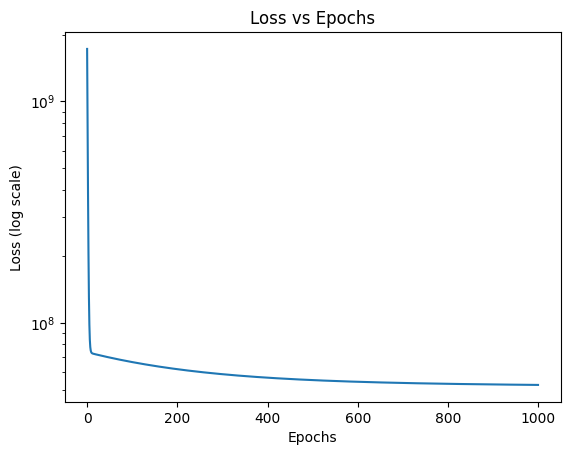

In [31]:
plt.plot(losses)
plt.yscale("log")
plt.xlabel("Epochs")
plt.ylabel("Loss (log scale)")
plt.title("Loss vs Epochs")
plt.show()

In [26]:
print("Final Weights:", w)
print("Final Bias:", b)

Final Weights: [ 764.75405919 1371.03430441]
Final Bias: 321.73641174472493


In [29]:
# Predict income for a new person
new_person = np.array([35, 6])  # age 35, experience 6 years

predicted_income = np.dot(new_person, w) + b

print("Predicted Income:", predicted_income)

Predicted Income: 35314.33430986123


## Final Evaluation

#Is the prediction reasonable?
 Yes, if it lies within the income range of the dataset.

#Does it interpolate smoothly?
 Yes. Linear regression produces smooth predictions between data points.

#Why is this better than threshold rules?
 Threshold rules cannot predict exact income.
 Linear regression produces precise numeric output.